# Analiza Danych (Python) - Lekcja 2

1. [GitHub i GitKraken (z Lekcji 1)](#0.-GitHub-i-GitKraken-(z-Lekcji-1))
2. [Statystyka opisowa i praca z danymi](#1.-Statystyka-opisowa-i-praca-z-danymi)
3. [Typy danych i skale pomiarowe](#2.-Typy-danych-i-skale-pomiarowe)
4. [Miary tendencji centralnej i rozproszenia](#3.-Miary-tendencji-centralnej-i-rozproszenia)
5. [Wizualizacja rozkładów i zależności](#4.-Wizualizacja-rozkładów-i-zależności)
6. [Zadania](#5.-Zadania)
7. [Najczęstsze błędy](#Najczęstsze-błędy)


# 1. Statystyka opisowa i praca z danymi

## Populacja, próba, losowość

- **Populacja**: pełny zbiór obiektów, o których chcemy wnioskować.
- **Próba**: część populacji, którą realnie obserwujemy.
- **Losowość**: mechanizm doboru i zmienności wyników; wpływa na to, czy wnioski da się uogólniać.

W praktyce analitycznej:
- pracujemy na próbie,
- opisujemy próbę statystykami opisowymi,
- oceniamy, na ile wynik może reprezentować populację.

## Cel tej lekcji

- poprawnie opisać dane liczbowe i kategoryczne,
- rozumieć, które miary mają sens dla danej skali,
- tworzyć wykresy rozkładów i zależności,
- formułować krótkie, poprawne wnioski z danych.


# 2. Typy danych i skale pomiarowe

## Typy danych w pandas

Najczęściej spotkasz:
- `object` / `string` (tekst),
- `int64`, `float64` (liczby),
- `category` (kategorie),
- `datetime64[ns]` (daty).

## Skale pomiarowe (statystyka)

- **Nominalna**: kategorie bez porządku (np. płeć, grupa).
- **Porządkowa**: kategorie z porządkiem (np. skala Likerta 1-5).
- **Przedziałowa**: różnice mają sens, brak naturalnego zera.
- **Ilorazowa**: różnice i ilorazy mają sens, istnieje zero absolutne.

Zasada praktyczna: najpierw ustal skalę zmiennej, dopiero potem dobieraj miary i wykres.


# 3. Miary tendencji centralnej i rozproszenia

## Najważniejsze miary

- Tendencja centralna: `mean`, `median`, `mode`.
- Rozproszenie: `std`, `var`, `min`, `max`, `quantile`, `IQR`.
- Rozkład empiryczny: jak często obserwujemy wartości (histogram, gęstość, percentyle).

W praktyce:
- dla rozkładów skośnych częściej raportujemy medianę i IQR,
- dla rozkładów zbliżonych do normalnych często raportujemy średnią i odchylenie standardowe.


# 4. Wizualizacja rozkładów i zależności

## Minimalny zestaw wykresów

- histogram + KDE: rozkład jednej zmiennej liczbowej,
- boxplot: porównanie rozkładów między grupami + obserwacje odstające,
- barplot/countplot: zmienne kategoryczne,
- scatterplot: zależność między dwiema zmiennymi liczbowymi.

Dobra praktyka:
- zawsze podpisane osie,
- tytuł mówiący, co porównujesz,
- krótki komentarz interpretacyjny pod wykresem.


# 5. Zadania

## Pliki do ćwiczeń

Pliki wejściowe znajdują się w folderze `dane_lekcja2/`:

- `participants.csv`
- `survey_likert.csv`
- `experiment_trials.csv`
- `outliers_rt.csv` 


## Zadanie 1

Cel: szybka diagnostyka jakości danych i struktury tabeli.

Wprowadzenie:
Najpierw zawsze sprawdź rozmiar danych, typy kolumn i braki. To pozwala uniknąć błędnych analiz na kolejnych etapach.

Instrukcja:
1. Wczytaj `participants.csv`.
2. Sprawdź liczbę wierszy i kolumn.
3. Sprawdź typy kolumn.
4. Policz braki danych w każdej kolumnie.

Wymagane funkcje:
- `pd.read_csv()`
- `DataFrame.shape`
- `DataFrame.info()`
- `DataFrame.isna()`
- `DataFrame.sum()`

Kryterium zaliczenia:
- pokazany rozmiar danych, typy i liczba braków.

Checkpoint:
- pokaż prowadzącemu wynik `df.info()` i `df.isna().sum()`.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html


In [1]:
# Miejsce na Twoje rozwiązanie.
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("dane_lekcja2/participants.csv")

print("SHAPE:", df.shape)
print()
df.info()
print()
print("DTYPES:")
print(df.dtypes)
print()
print("BRAKI (isna().sum()):")
print(df.isna().sum())

df.head()


SHAPE: (800, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   participant_id    800 non-null    int64  
 1   age               800 non-null    int64  
 2   gender            800 non-null    object 
 3   group             800 non-null    object 
 4   education         800 non-null    object 
 5   sleep_hours       777 non-null    float64
 6   stress_level      786 non-null    float64
 7   reaction_time_ms  800 non-null    float64
 8   memory_score      786 non-null    float64
 9   attention_score   800 non-null    float64
 10  session_date      800 non-null    object 
 11  city              800 non-null    object 
dtypes: float64(5), int64(2), object(5)
memory usage: 75.1+ KB

DTYPES:
participant_id        int64
age                   int64
gender               object
group                object
education            object
sleep_h

,participant_id,age,gender,group,education,sleep_hours,stress_level,reaction_time_ms,memory_score,attention_score,session_date,city
0,1,22,M,kontrolna,magister,9.0,10.0,420.6,62.4,50.0,2025-12-20,Szczecin
1,2,38,K,kontrolna,licencjat,5.0,1.0,519.3,76.0,52.4,2025-12-14,Lodz
2,3,30,M,kontrolna,magister,NaN,9.0,535.4,68.4,70.2,2025-12-07,Poznan
3,4,32,K,eksperymentalna,magister,7.3,2.0,437.1,59.3,81.3,2025-12-26,Szczecin
4,5,37,M,kontrolna,licencjat,8.3,1.0,660.6,77.1,67.7,2025-11-28,Szczecin


## Zadanie 2

Cel: rozpoznanie typów danych i skal pomiarowych.

Wprowadzenie:
Typ techniczny (`dtype`) i skala statystyczna to nie to samo. Np. skala Likerta jest zwykle liczbowo zapisana jako `int`, ale statystycznie jest porządkowa.

Instrukcja:
1. Dla każdej kolumny z `participants.csv` zapisz proponowaną skalę: nominalna/porządkowa/ilorazowa.
2. Utwórz tabelę podsumowującą z kolumnami: `zmienna`, `dtype`, `skala`, `uzasadnienie`.

Wymagane funkcje:
- `DataFrame.dtypes`
- `pd.DataFrame()`

Kryterium zaliczenia:
- tabela zawiera wszystkie kolumny i sensowne przypisanie skali.

Checkpoint:
- pokaż gotową tabelę klasyfikacji zmiennych.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html


In [2]:
# Miejsce na Twoje rozwiązanie.
skale = [
    {
        "zmienna": "participant_id",
        "dtype": str(df["participant_id"].dtype),
        "skala": "nominalna",
        "uzasadnienie": "Identyfikator uczestnika (etykieta)",
    },
    {
        "zmienna": "age",
        "dtype": str(df["age"].dtype),
        "skala": "ilorazowa",
        "uzasadnienie": "Wiek w latach; ma sens 0 i ilorazy",
    },
    {
        "zmienna": "gender",
        "dtype": str(df["gender"].dtype),
        "skala": "nominalna",
        "uzasadnienie": "Kategorie bez porządku",
    },
    {
        "zmienna": "group",
        "dtype": str(df["group"].dtype),
        "skala": "nominalna",
        "uzasadnienie": "Przynależność do grupy",
    },
    {
        "zmienna": "education",
        "dtype": str(df["education"].dtype),
        "skala": "porządkowa",
        "uzasadnienie": "Poziomy wykształcenia mają porządek",
    },
    {
        "zmienna": "sleep_hours",
        "dtype": str(df["sleep_hours"].dtype),
        "skala": "ilorazowa",
        "uzasadnienie": "Godziny snu; ma sens 0",
    },
    {
        "zmienna": "stress_level",
        "dtype": str(df["stress_level"].dtype),
        "skala": "porządkowa",
        "uzasadnienie": "Skala samoopisu (typowo porządkowa)",
    },
    {
        "zmienna": "reaction_time_ms",
        "dtype": str(df["reaction_time_ms"].dtype),
        "skala": "ilorazowa",
        "uzasadnienie": "Czas reakcji w ms; ma sens 0",
    },
    {
        "zmienna": "memory_score",
        "dtype": str(df["memory_score"].dtype),
        "skala": "ilorazowa",
        "uzasadnienie": "Wynik liczbowy; średnia/mediana mają sens",
    },
    {
        "zmienna": "attention_score",
        "dtype": str(df["attention_score"].dtype),
        "skala": "ilorazowa",
        "uzasadnienie": "Wynik liczbowy; średnia/mediana mają sens",
    },
    {
        "zmienna": "session_date",
        "dtype": str(df["session_date"].dtype),
        "skala": "przedziałowa",
        "uzasadnienie": "Data/czas: różnice mają sens, zero umowne",
    },
    {
        "zmienna": "city",
        "dtype": str(df["city"].dtype),
        "skala": "nominalna",
        "uzasadnienie": "Kategorie bez porządku",
    },
]

tabela_skale = pd.DataFrame(skale)
tabela_skale


,zmienna,dtype,skala,uzasadnienie
0,participant_id,int64,nominalna,Identyfikator uczestnika (etykieta)
1,age,int64,ilorazowa,Wiek w latach; ma sens 0 i ilorazy
2,gender,object,nominalna,Kategorie bez porządku
3,group,object,nominalna,Przynależność do grupy
4,education,object,porządkowa,Poziomy wykształcenia mają porządek
5,sleep_hours,float64,ilorazowa,Godziny snu; ma sens 0
6,stress_level,float64,porządkowa,Skala samoopisu (typowo porządkowa)
7,reaction_time_ms,float64,ilorazowa,Czas reakcji w ms; ma sens 0
8,memory_score,float64,ilorazowa,Wynik liczbowy; średnia/mediana mają sens
9,attention_score,float64,ilorazowa,Wynik liczbowy; średnia/mediana mają sens


## Zadanie 3

Cel: obliczenie miar tendencji centralnej i rozproszenia.

Wprowadzenie:
Opis statystyczny powinien zawierać zarówno miary centralne, jak i rozproszenie. Sama średnia nie wystarcza.

Instrukcja:
1. Dla zmiennych `reaction_time_ms`, `memory_score`, `attention_score` oblicz:
- średnią,
- medianę,
- dominantę,
- odchylenie standardowe,
- kwartyle (`Q1`, `Q3`) i `IQR`.
2. Zbierz wynik do jednej tabeli.

Wymagane funkcje:
- `DataFrame.mean()`
- `DataFrame.median()`
- `DataFrame.mode()`
- `DataFrame.std()`
- `DataFrame.quantile()`

Kryterium zaliczenia:
- jedna tabela z kompletem miar dla trzech zmiennych.

Checkpoint:
- pokaż tabelę i krótko wskaż, która zmienna ma największe rozproszenie.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mean.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.median.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mode.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.std.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.quantile.html


In [3]:
# Miejsce na Twoje rozwiązanie.
cols = ["reaction_time_ms", "memory_score", "attention_score"]

q1 = df[cols].quantile(0.25)
q3 = df[cols].quantile(0.75)

miary = pd.DataFrame(index=cols)
miary["mean"] = df[cols].mean()
miary["median"] = df[cols].median()
miary["mode"] = df[cols].mode().iloc[0]
miary["std"] = df[cols].std()
miary["q1"] = q1
miary["q3"] = q3
miary["iqr"] = q3 - q1

miary


,mean,median,mode,std,q1,q3,iqr
reaction_time_ms,546.827000,542.95,537.8,84.917711,488.875,604.400,115.525
memory_score,69.151908,69.20,63.2,11.871745,61.300,77.600,16.300
attention_score,67.604000,68.20,67.8,11.754694,59.700,75.325,15.625


## Zadanie 4

Cel: analiza rozkładu empirycznego jednej zmiennej.

Wprowadzenie:
Rozkład empiryczny pokazuje, gdzie koncentrują się obserwacje i czy występuje skośność.

Instrukcja:
1. Dla `reaction_time_ms` narysuj histogram (`bins` min. 20) i linię KDE.
2. Oblicz percentyle: 10%, 25%, 50%, 75%, 90%.
3. Napisz 2-3 zdania interpretacji.

Wymagane funkcje:
- `sns.histplot()`
- parametry `bins`, `kde`
- `Series.quantile()`
- `plt.title()`, `plt.xlabel()`, `plt.ylabel()`

Kryterium zaliczenia:
- poprawny wykres + percentyle + krótka interpretacja.

Checkpoint:
- pokaż wykres i wartości percentyli.

Dokumentacja:
- https://seaborn.pydata.org/generated/seaborn.histplot.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.title.html


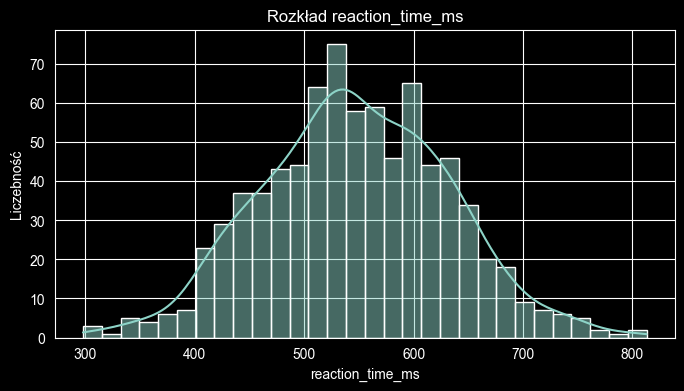

Percentyle reaction_time_ms:
0.10    436.520
0.25    488.875
0.50    542.950
0.75    604.400
0.90    651.130
Name: reaction_time_ms, dtype: float64

Interpretacja: Rozkład jest w przybliżeniu symetryczny (skośność=0.03). Mediana=543.0 ms, a 90 percentyl=651.1 ms.


In [4]:
# Miejsce na Twoje rozwiązanie.
rt = df["reaction_time_ms"].dropna()

plt.figure(figsize=(8, 4))
sns.histplot(rt, bins=30, kde=True)
plt.title("Rozkład reaction_time_ms")
plt.xlabel("reaction_time_ms")
plt.ylabel("Liczebność")
plt.show()

percentyle = rt.quantile([0.10, 0.25, 0.50, 0.75, 0.90])
print("Percentyle reaction_time_ms:")
print(percentyle)

skew = rt.skew()
if skew > 0.5:
    opis = "prawostronnie skośny"
elif skew < -0.5:
    opis = "lewostronnie skośny"
else:
    opis = "w przybliżeniu symetryczny"

print(
    "\nInterpretacja:",
    f"Rozkład jest {opis} (skośność={skew:.2f}).",
    f"Mediana={percentyle.loc[0.5]:.1f} ms, a 90 percentyl={percentyle.loc[0.9]:.1f} ms.",
)


## Zadanie 5

Cel: porównanie grup przy użyciu statystyki opisowej.

Wprowadzenie:
`groupby` pozwala porównać profile grup bez budowy modeli inferencyjnych.

Instrukcja:
1. Policz średni i medianowy `reaction_time_ms` oraz `memory_score` w podziale na `group`.
2. Rozszerz analizę o podział jednocześnie po `group` i `gender`.

Wymagane funkcje:
- `DataFrame.groupby()`
- `DataFrame.agg()`

Kryterium zaliczenia:
- dwie tabele: (a) wg `group`, (b) wg `group` i `gender`.

Checkpoint:
- wskaż, która grupa ma szybszy średni czas reakcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
- https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.agg.html


In [5]:
# Miejsce na Twoje rozwiązanie.
tabela_group = df.groupby("group").agg(
    rt_mean=("reaction_time_ms", "mean"),
    rt_median=("reaction_time_ms", "median"),
    memory_mean=("memory_score", "mean"),
    memory_median=("memory_score", "median"),
)

tabela_group_gender = df.groupby(["group", "gender"]).agg(
    rt_mean=("reaction_time_ms", "mean"),
    rt_median=("reaction_time_ms", "median"),
    memory_mean=("memory_score", "mean"),
    memory_median=("memory_score", "median"),
)

print("PODSUMOWANIE WG group:\n", tabela_group)
print("\nPODSUMOWANIE WG group i gender:\n", tabela_group_gender)

najszybsza = tabela_group["rt_mean"].idxmin()
print("\nNajszybszy średni czas reakcji ma grupa:", najszybsza)


PODSUMOWANIE WG group:
                    rt_mean  rt_median  memory_mean  memory_median
group                                                            
eksperymentalna  534.77425     533.45    69.394898          70.00
kontrolna        558.87975     563.95    68.910152          67.95

PODSUMOWANIE WG group i gender:
                            rt_mean  rt_median  memory_mean  memory_median
group           gender                                                   
eksperymentalna K       531.700000      532.6    67.658416          69.05
                M       538.006154      537.6    71.241053          71.15
kontrolna       K       558.719487      564.2    69.106283          67.80
                M       559.032195      563.7    68.725616          68.20

Najszybszy średni czas reakcji ma grupa: eksperymentalna


## Zadanie 6

Cel: wizualizacja zależności między zmiennymi liczbowymi.

Wprowadzenie:
Na tym etapie nie testujemy hipotez, tylko opisujemy siłę i kierunek zależności.

Instrukcja:
1. Oblicz macierz korelacji dla zmiennych liczbowych z `participants.csv`.
2. Narysuj heatmapę korelacji.
3. Narysuj `scatterplot` dla `sleep_hours` vs `memory_score`.

Wymagane funkcje:
- `DataFrame.corr()`
- `sns.heatmap()`
- `sns.scatterplot()`
- parametr `annot=True` (heatmap)

Kryterium zaliczenia:
- macierz korelacji + 2 wykresy (heatmap + scatterplot).

Checkpoint:
- wskaż jedną dodatnią i jedną ujemną zależność.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html
- https://seaborn.pydata.org/generated/seaborn.heatmap.html
- https://seaborn.pydata.org/generated/seaborn.scatterplot.html


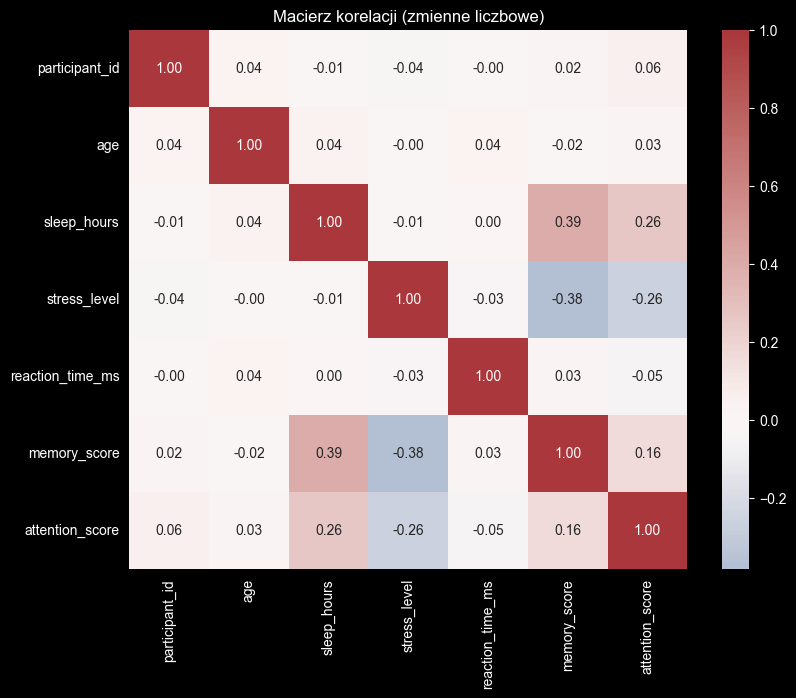

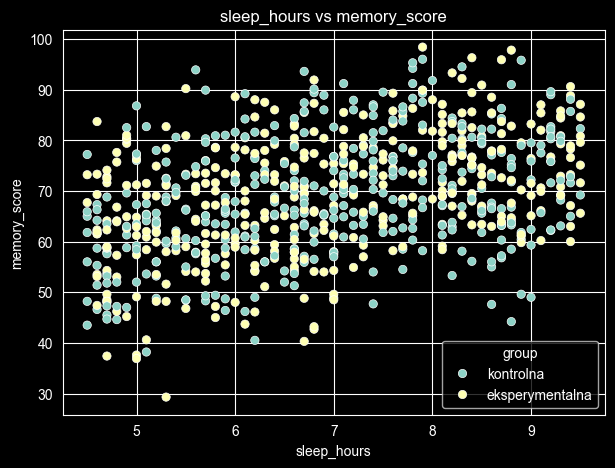

Najsilniejsza ujemna korelacja:
 stress_level  memory_score   -0.381877
dtype: float64

Najsilniejsza dodatnia korelacja:
 memory_score  sleep_hours    0.392135
dtype: float64


In [6]:
# Miejsce na Twoje rozwiązanie.
num = df.select_dtypes(include="number")
corr = num.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Macierz korelacji (zmienne liczbowe)")
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="sleep_hours", y="memory_score", hue="group")
plt.title("sleep_hours vs memory_score")
plt.xlabel("sleep_hours")
plt.ylabel("memory_score")
plt.show()

pairs = corr.where(~(corr == 1)).stack().sort_values()
print("Najsilniejsza ujemna korelacja:\n", pairs.head(1))
print("\nNajsilniejsza dodatnia korelacja:\n", pairs.tail(1))


## Zadanie 7

Cel: detekcja obserwacji odstających.

Wprowadzenie:
Outliery silnie wpływają na średnią i odchylenie standardowe, dlatego warto je diagnozować osobno.

Instrukcja:
1. Wczytaj `outliers_rt.csv`.
2. Dla `rt_ms` oblicz `Q1`, `Q3`, `IQR`.
3. Wyznacz dolną i górną granicę metody IQR (`Q1 - 1.5*IQR`, `Q3 + 1.5*IQR`).
4. Odfiltruj obserwacje odstające i policz ich liczbę.
5. Pokaż boxplot `rt_ms` w podziale na `group`.

Wymagane funkcje:
- `Series.quantile()`
- filtrowanie logiczne `DataFrame`
- `sns.boxplot()`

Kryterium zaliczenia:
- podane granice IQR, liczba outlierów i wykres boxplot.

Checkpoint:
- pokaż tabelę z pierwszymi 10 outlierami.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html
- https://seaborn.pydata.org/generated/seaborn.boxplot.html


Q1=517.42, Q3=606.47, IQR=89.05
Granice IQR: [383.85, 740.05]
Liczba outlierów: 27


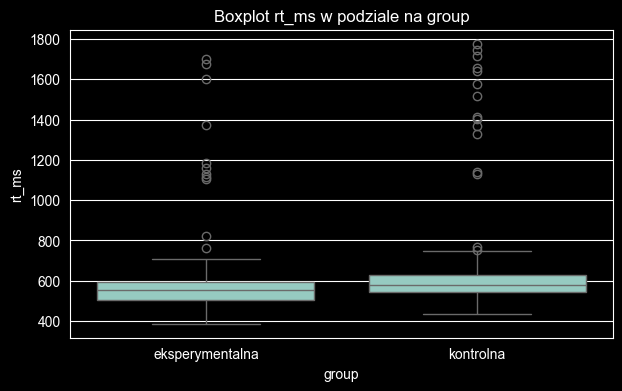

,observation_id,group,rt_ms
1,2,kontrolna,1400.2
16,17,eksperymentalna,1107.2
52,53,kontrolna,1653.7
55,56,kontrolna,1411.8
72,73,kontrolna,1776.4
131,132,eksperymentalna,824.2
136,137,eksperymentalna,1114.6
141,142,kontrolna,767.3
178,179,eksperymentalna,1159.9
218,219,kontrolna,748.8


In [7]:
# Miejsce na Twoje rozwiązanie.
out = pd.read_csv("dane_lekcja2/outliers_rt.csv")

q1 = out["rt_ms"].quantile(0.25)
q3 = out["rt_ms"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = out[(out["rt_ms"] < lower) | (out["rt_ms"] > upper)]

print(f"Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
print(f"Granice IQR: [{lower:.2f}, {upper:.2f}]")
print("Liczba outlierów:", outliers.shape[0])

plt.figure(figsize=(7, 4))
sns.boxplot(data=out, x="group", y="rt_ms")
plt.title("Boxplot rt_ms w podziale na group")
plt.xlabel("group")
plt.ylabel("rt_ms")
plt.show()

outliers.head(10)


## Zadanie 8

Cel: połączenie opisu liczbowego i wizualnego w krótkim raporcie.

Wprowadzenie:
To mini-symulacja realnej pracy analitycznej: wybierasz kluczowe miary i wykresy, a potem formułujesz wnioski.

Instrukcja:
1. Użyj `participants.csv` i przygotuj 1 tabelę podsumowującą (min. 4 miary).
2. Dodaj 2 wykresy: jeden rozkładu, jeden zależności.
3. Napisz 5 krótkich wniosków (każdy 1 zdanie) opartych na danych.

Wymagane funkcje:
- dowolne z poprzednich zadań (`describe`, `groupby`, `histplot`, `boxplot`, `scatterplot`, `heatmap`).

Kryterium zaliczenia:
- tabela + 2 wykresy + 5 wniosków spójnych z wynikami.

Checkpoint:
- przedstaw mini-raport w jednej sekcji notebooka.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html
- https://seaborn.pydata.org/


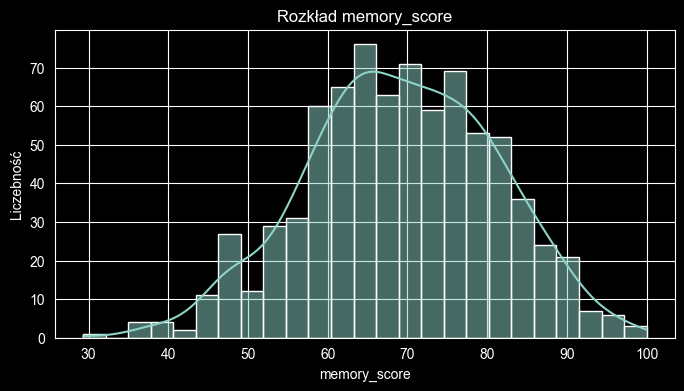

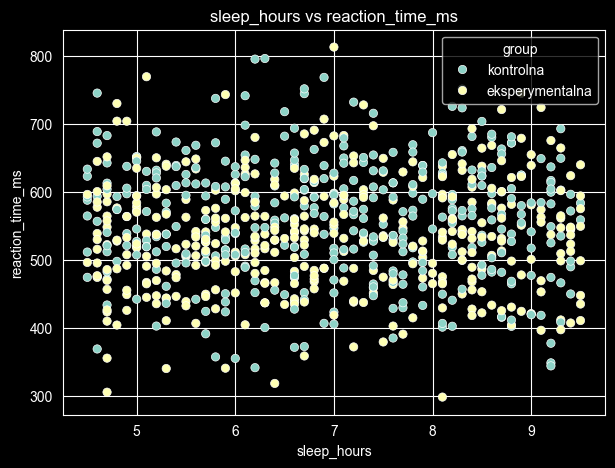

- Próba ma 800 obserwacji.
- Średni reaction_time_ms = 546.8 ms, a mediana = 543.0 ms.
- Najniższy średni reaction_time_ms ma grupa eksperymentalna (534.8 ms).
- Korelacja sleep_hours z memory_score wynosi 0.39.
- Łączna liczba braków danych w tabeli to 51.


In [8]:
# Miejsce na Twoje rozwiązanie.
tabela = df[["reaction_time_ms", "memory_score", "attention_score", "sleep_hours"]].describe().T
tabela

plt.figure(figsize=(8, 4))
sns.histplot(df["memory_score"], bins=25, kde=True)
plt.title("Rozkład memory_score")
plt.xlabel("memory_score")
plt.ylabel("Liczebność")
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="sleep_hours", y="reaction_time_ms", hue="group")
plt.title("sleep_hours vs reaction_time_ms")
plt.xlabel("sleep_hours")
plt.ylabel("reaction_time_ms")
plt.show()

n = len(df)
rt_mean = df["reaction_time_ms"].mean()
rt_median = df["reaction_time_ms"].median()
corr_sm = df["sleep_hours"].corr(df["memory_score"])
group_rt = df.groupby("group")["reaction_time_ms"].mean().sort_values()
missing_total = int(df.isna().sum().sum())

wnioski = [
    f"Próba ma {n} obserwacji.",
    f"Średni reaction_time_ms = {rt_mean:.1f} ms, a mediana = {rt_median:.1f} ms.",
    f"Najniższy średni reaction_time_ms ma grupa {group_rt.index[0]} ({group_rt.iloc[0]:.1f} ms).",
    f"Korelacja sleep_hours z memory_score wynosi {corr_sm:.2f}.",
    f"Łączna liczba braków danych w tabeli to {missing_total}.",
]

for w in wnioski:
    print("-", w)


## Zadanie 9 - dodatkowe

Cel: praca na skali porządkowej (Likert) i świadomy dobór miar.

Wprowadzenie:
Dane Likerta są porządkowe, więc poza średnią warto raportować medianę i rozkład odpowiedzi.

Instrukcja:
1. Wczytaj `survey_likert.csv`.
2. Dla pytań `q1`-`q8` oblicz medianę i dominantę.
3. Dla każdego pytania policz rozkład odpowiedzi (`value_counts`) i udział procentowy.

Wymagane funkcje:
- `pd.read_csv()`
- `DataFrame.median()`
- `DataFrame.mode()`
- `Series.value_counts()`
- parametr `normalize=True`

Kryterium zaliczenia:
- tabela median i dominant + min. jedna tabela rozkładu procentowego.

Checkpoint:
- wskaż pytanie z najwyższą medianą.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.median.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mode.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html


In [9]:
# Miejsce na Twoje rozwiązanie.
likert = pd.read_csv("dane_lekcja2/survey_likert.csv")
qcols = [f"q{i}" for i in range(1, 9)]

mediany = likert[qcols].median()
dominanty = likert[qcols].mode().iloc[0]

podsum = pd.DataFrame({"mediana": mediany, "dominanta": dominanty}).sort_values(
    by="mediana", ascending=False
)
print(podsum)

naj_q = podsum.index[0]
print("\nPytanie z najwyższą medianą:", naj_q)

rozklad_proc = (
    likert[naj_q]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)
rozklad_proc


    mediana  dominanta
q1      3.0          1
q2      3.0          2
q3      3.0          3
q4      3.0          4
q5      3.0          3
q6      3.0          1
q7      3.0          5
q8      3.0          1

Pytanie z najwyższą medianą: q1


q1
1    21.4
2    21.3
3    19.7
4    18.7
5    18.9
Name: proportion, dtype: float64

## Zadanie 10 - dodatkowe

Cel: porównanie rozkładów między warunkami eksperymentalnymi.

Wprowadzenie:
Same średnie nie pokazują pełnego obrazu. Rozkład może różnić się szerokością i skośnością.

Instrukcja:
1. Wczytaj `experiment_trials.csv`.
2. Narysuj boxplot `rt_ms` w podziale na `condition`.
3. Dla każdej `condition` policz medianę i IQR dla `rt_ms`.

Wymagane funkcje:
- `pd.read_csv()`
- `sns.boxplot()`
- `groupby()` + `agg()`
- `quantile()`

Kryterium zaliczenia:
- wykres + tabela mediany i IQR dla A/B/C.

Checkpoint:
- wskaż warunek o największym rozproszeniu.

Dokumentacja:
- https://seaborn.pydata.org/generated/seaborn.boxplot.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html


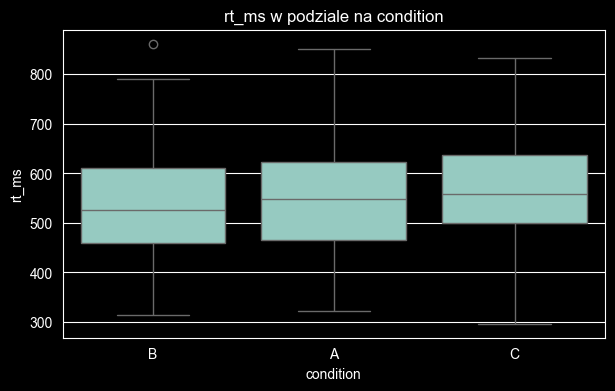

           mediana       q1      q3      iqr
condition                                   
A           549.05  466.575  623.25  156.675
B           525.90  458.700  611.35  152.650
C           559.40  500.100  637.00  136.900

Największe rozproszenie (IQR) ma condition: A


In [10]:
# Miejsce na Twoje rozwiązanie.
trials = pd.read_csv("dane_lekcja2/experiment_trials.csv")

plt.figure(figsize=(7, 4))
sns.boxplot(data=trials, x="condition", y="rt_ms")
plt.title("rt_ms w podziale na condition")
plt.xlabel("condition")
plt.ylabel("rt_ms")
plt.show()

stats = trials.groupby("condition")["rt_ms"].agg(
    mediana="median",
    q1=lambda s: s.quantile(0.25),
    q3=lambda s: s.quantile(0.75),
)
stats["iqr"] = stats["q3"] - stats["q1"]
stats = stats.sort_values(by="iqr", ascending=False)

print(stats)
print("\nNajwiększe rozproszenie (IQR) ma condition:", stats.index[0])


## Zadanie 11 - dodatkowe

Cel: analiza trafności odpowiedzi (`correct`) względem trudności zadania.

Wprowadzenie:
To przykład statystyki opisowej dla zmiennej binarnej (0/1): średnia = odsetek sukcesu.

Instrukcja:
1. W `experiment_trials.csv` policz odsetek poprawnych odpowiedzi dla poziomów `difficulty`.
2. Zwizualizuj wynik na wykresie słupkowym.
3. Dodaj etykiety procentowe nad słupkami.

Wymagane funkcje:
- `groupby()` + `mean()`
- `sns.barplot()` albo `plt.bar()`
- `matplotlib` (`plt.text` lub `bar_label`)

Kryterium zaliczenia:
- poprawny ranking poziomów trudności wg accuracy.

Checkpoint:
- wskaż różnicę (w p.p.) między `easy` i `hard`.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.SeriesGroupBy.mean.html
- https://seaborn.pydata.org/generated/seaborn.barplot.html


difficulty
easy      0.904372
medium    0.774359
hard      0.610656
Name: correct, dtype: float64


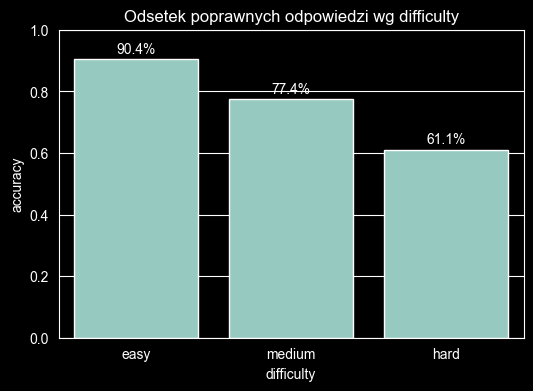

Różnica easy - hard: 29.4 p.p.


In [11]:
# Miejsce na Twoje rozwiązanie.
acc = trials.groupby("difficulty")["correct"].mean().sort_values(ascending=False)
print(acc)

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=acc.index, y=acc.values)
ax.set_title("Odsetek poprawnych odpowiedzi wg difficulty")
ax.set_xlabel("difficulty")
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1)

for i, v in enumerate(acc.values):
    ax.text(i, v + 0.02, f"{v*100:.1f}%", ha="center")

plt.show()

if "easy" in acc.index and "hard" in acc.index:
    diff_pp = (acc.loc["easy"] - acc.loc["hard"]) * 100
    print(f"Różnica easy - hard: {diff_pp:.1f} p.p.")


## Zadanie 12 - dodatkowe

Cel: standaryzacja (z-score) i porównanie obserwacji na wspólnej skali.

Wprowadzenie:
Standaryzacja umożliwia porównywanie zmiennych mierzonych w różnych jednostkach.

Instrukcja:
1. W `participants.csv` wylicz z-score dla `reaction_time_ms` i `memory_score`.
2. Dodaj kolumny `rt_z` i `memory_z`.
3. Sprawdź, ilu uczestników ma `rt_z > 2` lub `rt_z < -2`.

Wymagane funkcje:
- operacje wektorowe na kolumnach
- `Series.mean()`
- `Series.std()`
- filtrowanie logiczne

Kryterium zaliczenia:
- poprawnie utworzone kolumny z-score i liczba skrajnych obserwacji.

Checkpoint:
- pokaż 10 rekordów o najwyższym `rt_z`.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.Series.mean.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.std.html


In [12]:
# Miejsce na Twoje rozwiązanie.
df = df.copy()

df["rt_z"] = (df["reaction_time_ms"] - df["reaction_time_ms"].mean()) / df[
    "reaction_time_ms"
].std()
df["memory_z"] = (df["memory_score"] - df["memory_score"].mean()) / df[
    "memory_score"
].std()

skrajne = df[(df["rt_z"] > 2) | (df["rt_z"] < -2)]
print("Liczba uczestników z rt_z > 2 lub rt_z < -2:", skrajne.shape[0])

df.sort_values(by="rt_z", ascending=False).head(10)[
    ["participant_id", "reaction_time_ms", "rt_z", "memory_score", "memory_z"]
]


Liczba uczestników z rt_z > 2 lub rt_z < -2: 38


,participant_id,reaction_time_ms,rt_z,memory_score,memory_z
264,265,812.9,3.133304,48.5,-1.739585
502,503,796.1,2.935465,72.3,0.265175
287,288,795.2,2.924867,49.0,-1.697468
798,799,769.3,2.619866,62.0,-0.602431
268,269,768.3,2.608090,86.0,1.419176
587,588,751.5,2.410251,68.4,-0.063336
774,775,751.2,2.406718,73.7,0.383102
670,671,745.2,2.336062,64.2,-0.417117
238,239,744.9,2.332529,59.8,-0.787745
279,280,744.4,2.326641,85.7,1.393906


## Zadanie 13 - dodatkowe

Cel: praca z przedziałami wartości (binning).

Wprowadzenie:
Binning upraszcza interpretację i pozwala porównywać profile grup.

Instrukcja:
1. Podziel `age` na przedziały: `18-22`, `23-27`, `28-32`, `33+`.
2. Policz liczebność uczestników w każdym przedziale.
3. Porównaj średni `memory_score` między przedziałami wieku.

Wymagane funkcje:
- `pd.cut()`
- `Series.value_counts()`
- `groupby()` + `mean()`

Kryterium zaliczenia:
- poprawna kolumna przedziałów wieku i tabela porównawcza.

Checkpoint:
- wskaż przedział wieku z najwyższym średnim `memory_score`.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.cut.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html


In [13]:
# Miejsce na Twoje rozwiązanie.
bins = [17, 22, 27, 32, 200]
labels = ["18-22", "23-27", "28-32", "33+"]
df["age_bin"] = pd.cut(df["age"], bins=bins, labels=labels)

liczebnosci = df["age_bin"].value_counts().sort_index()
srednie_memory = df.groupby("age_bin")["memory_score"].mean().sort_values(ascending=False)

print("Liczebności w przedziałach wieku:\n", liczebnosci)
print("\nŚredni memory_score wg przedziału wieku:\n", srednie_memory)

print("\nNajwyższy średni memory_score ma przedział:", srednie_memory.index[0])


Liczebności w przedziałach wieku:
 age_bin
18-22    146
23-27    185
28-32    228
33+      241
Name: count, dtype: int64

Średni memory_score wg przedziału wieku:
 age_bin
28-32    69.574890
18-22    69.490909
23-27    69.135165
33+      68.547436
Name: memory_score, dtype: float64

Najwyższy średni memory_score ma przedział: 28-32


/var/folders/x3/fmf5wmjn5493djpqjg1f_xgc0000gn/T/ipykernel_11561/73027000.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  srednie_memory = df.groupby("age_bin")["memory_score"].mean().sort_values(ascending=False)


## Zadanie 14 - dodatkowe

Cel: porównanie średniej i mediany przy obecności obserwacji odstających.

Wprowadzenie:
Outliery mogą silnie przesuwać średnią, ale zwykle mniej wpływają na medianę.

Instrukcja:
1. Użyj `outliers_rt.csv`.
2. Policz średnią i medianę `rt_ms` dla całego zbioru.
3. Usuń outliery metodą IQR.
4. Ponownie policz średnią i medianę po oczyszczeniu.
5. Porównaj wyniki w krótkim komentarzu.

Wymagane funkcje:
- `mean()`, `median()`
- `quantile()`
- filtrowanie DataFrame

Kryterium zaliczenia:
- tabela/przedstawienie wyników „przed” i „po” oczyszczeniu.

Checkpoint:
- wskaż, która miara zmieniła się bardziej.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.Series.mean.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.median.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html


In [14]:
# Miejsce na Twoje rozwiązanie.
out = pd.read_csv("dane_lekcja2/outliers_rt.csv")

before_mean = out["rt_ms"].mean()
before_median = out["rt_ms"].median()

q1 = out["rt_ms"].quantile(0.25)
q3 = out["rt_ms"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

clean = out[(out["rt_ms"] >= lower) & (out["rt_ms"] <= upper)]
after_mean = clean["rt_ms"].mean()
after_median = clean["rt_ms"].median()

porownanie = pd.DataFrame(
    {
        "przed": [before_mean, before_median],
        "po": [after_mean, after_median],
    },
    index=["mean", "median"],
)
porownanie["zmiana_abs"] = (porownanie["po"] - porownanie["przed"]).abs()

print(porownanie)
print("\nBardziej zmieniła się miara:", porownanie["zmiana_abs"].idxmax())


           przed          po  zmiana_abs
mean    600.5844  560.222199   40.362201
median  567.2500  563.000000    4.250000

Bardziej zmieniła się miara: mean


## Zadanie 15 - dodatkowe

Cel: mini-dashboard analityczny podsumowujący dane z lekcji.

Wprowadzenie:
Końcowe zadanie integruje całą lekcję: dane, statystyki opisowe i wizualizacje w jednym spójnym raporcie.

Instrukcja:
1. Przygotuj sekcję podsumowania na podstawie `participants.csv` i `experiment_trials.csv`.
2. Umieść:
- 1 tabelę statystyk opisowych,
- 3 wykresy (rozkład, porównanie grup, zależność),
- 6 krótkich wniosków.
3. Każdy wniosek ma odnosić się do konkretnej liczby lub wykresu.

Wymagane funkcje:
- `describe()`, `groupby()`, `agg()`
- `histplot()`, `boxplot()`/`barplot()`, `scatterplot()`

Kryterium zaliczenia:
- spójna sekcja raportowa z danymi liczbowymi i poprawną interpretacją.

Checkpoint:
- zaprezentuj mini-dashboard w 2-3 minuty.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
- https://seaborn.pydata.org/


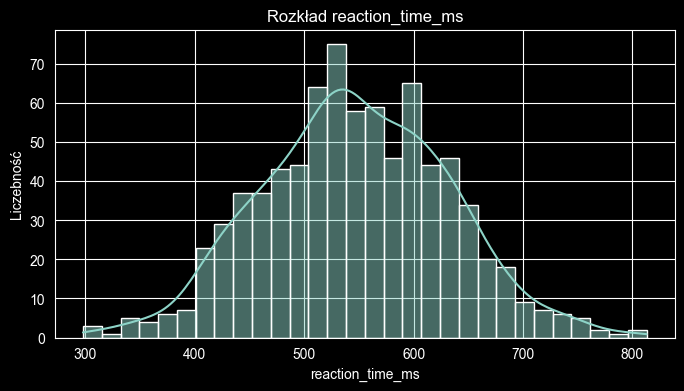

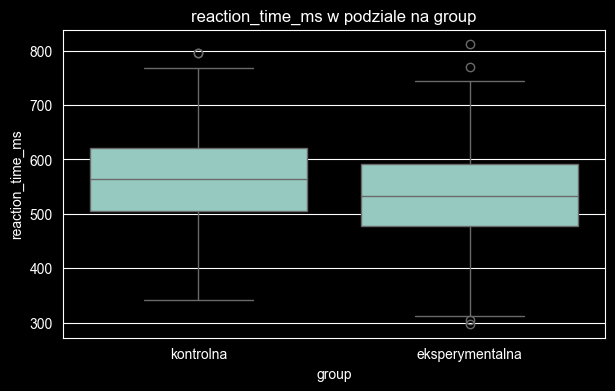

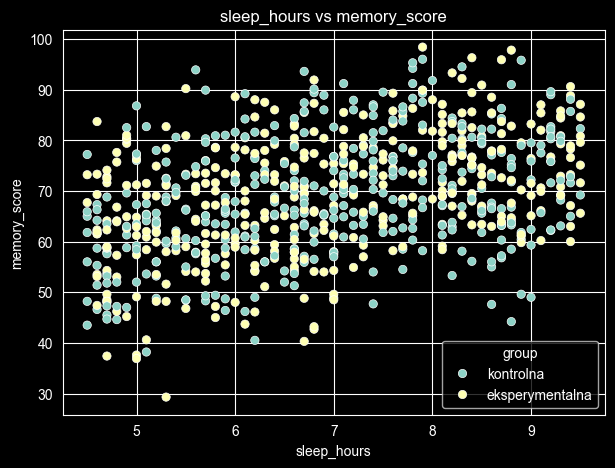

- Próba participants ma 800 osób.
- Najniższy średni reaction_time_ms ma grupa eksperymentalna (534.8 ms).
- Korelacja sleep_hours z memory_score: 0.39.
- Największy IQR rt_ms w trialach ma condition A (156.7 ms).
- Accuracy: easy=0.90, hard=0.61.
- Mediana memory_score w participants to 69.2.


In [15]:
# Miejsce na Twoje rozwiązanie.
trials = pd.read_csv("dane_lekcja2/experiment_trials.csv")

opis = df[[
    "reaction_time_ms",
    "memory_score",
    "attention_score",
    "sleep_hours",
    "stress_level",
]].describe().T
opis

plt.figure(figsize=(8, 4))
sns.histplot(df["reaction_time_ms"], bins=30, kde=True)
plt.title("Rozkład reaction_time_ms")
plt.xlabel("reaction_time_ms")
plt.ylabel("Liczebność")
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="group", y="reaction_time_ms")
plt.title("reaction_time_ms w podziale na group")
plt.xlabel("group")
plt.ylabel("reaction_time_ms")
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="sleep_hours", y="memory_score", hue="group")
plt.title("sleep_hours vs memory_score")
plt.xlabel("sleep_hours")
plt.ylabel("memory_score")
plt.show()

group_rt = df.groupby("group")["reaction_time_ms"].mean().sort_values()
best_group = group_rt.index[0]
best_group_val = group_rt.iloc[0]
corr_sm = df["sleep_hours"].corr(df["memory_score"])

cond_iqr = (
    trials.groupby("condition")["rt_ms"]
    .quantile(0.75)
    .sub(trials.groupby("condition")["rt_ms"].quantile(0.25))
    .sort_values(ascending=False)
)
worst_cond = cond_iqr.index[0]

acc = trials.groupby("difficulty")["correct"].mean()

wnioski = [
    f"Próba participants ma {len(df)} osób.",
    f"Najniższy średni reaction_time_ms ma grupa {best_group} ({best_group_val:.1f} ms).",
    f"Korelacja sleep_hours z memory_score: {corr_sm:.2f}.",
    f"Największy IQR rt_ms w trialach ma condition {worst_cond} ({cond_iqr.iloc[0]:.1f} ms).",
    f"Accuracy: easy={acc.get('easy', float('nan')):.2f}, hard={acc.get('hard', float('nan')):.2f}.",
    f"Mediana memory_score w participants to {df['memory_score'].median():.1f}.",
]

for w in wnioski:
    print("-", w)


## Najczęstsze błędy

- analizowanie średniej dla zmiennej porządkowej bez komentarza,
- pomijanie braków danych przed obliczeniami,
- brak podpisów osi i tytułu wykresu,
- mieszanie wniosków opisowych z przyczynowymi,
- interpretowanie korelacji jako dowodu przyczynowości.
